In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

In [ ]:
df = pd.read_csv('/content/Fai Datasets Rishu.csv')
display(df.head())

,Enter your age:,Which platform do you use the most daily?,"On average, how much time do you spend on social media per day?",When do you use social media the most?,What do you primarily use social media for?,Have you ever tried to take breaks from social media?,Do you feel social media affects your mental health?,What type of content do you engage with the most?,Have you ever experienced online drama or conflict because of social media?,Do you trust influencers' product recommendations?,Would you ever delete social media permanently?,Unnamed: 11
0,39,Instagram,5+ hours,Evening,Entertainment,No,No,Reels,Yes,No,Yes,NaN
1,55,Instagram,1-2 hours,Evening,Chatting with friend/family,Yes,Maybe,Reels,Yes,Sometimes,No,NaN
2,30,Instagram,1-2 hours,Late Night,Entertainment,Yes,No,Reels,Yes,No,No,NaN
3,35,INSTAGRAM,1-2 hours,Late Night,Chatting with friend/family,Yes,Maybe,Reels,No,No,Yes,NaN
4,38,Crunchyroll,5+ hours,Late Night,Entertainment,No,No,Reels,No,Sometimes,Yes,NaN


### Data Cleaning and Preparation
First, let's clean up the column names and standardize some categorical data for better analysis and visualization.

In [ ]:
# Clean column names: replace spaces with underscores, convert to lowercase
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace(':', '').str.replace('?', '')

# Rename some long columns for brevity
df = df.rename(columns={
    'enter_your_age': 'age',
    'which_platform_do_you_use_the_most_daily': 'most_used_platform',
    'on_average,_how_much_time_do_you_spend_on_social_media_per_day': 'time_spent_daily',
    'when_do_you_use_social_media_the_most': 'peak_usage_time',
    'what_do_you_primarily_use_social_media_for': 'primary_use',
    'have_you_ever_tried_to_take_breaks_from_social_media': 'tried_breaks',
    'do_you_feel_social_media_affects_your_mental_health': 'mental_health_impact',
    'what_type_of_content_do_you_engage_with_the_most': 'most_engaged_content',
    'have_you_ever_experienced_online_drama_or_conflict_because_of_social_media': 'experienced_drama',
    'do_you_trust_influencers_product_recommendations': 'trust_influencers_recs',
    'would_you_ever_delete_social_media_permanently': 'delete_permanently'
})

# Drop the 'unnamed: 11' column if it exists and is mostly null
if 'unnamed:_11' in df.columns:
    df = df.drop(columns=['unnamed:_11'])

# Standardize 'most_used_platform' column to consistent casing
df['most_used_platform'] = df['most_used_platform'].str.capitalize()

print("Cleaned DataFrame Info:")
df.info()
print("\nCleaned DataFrame Head:")
display(df.head())

Cleaned DataFrame Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1195 entries, 0 to 1194
Data columns (total 12 columns):
 #   Column                                             Non-Null Count  Dtype  
---  ------                                             --------------  -----  
 0   age                                                1195 non-null   int64  
 1   most_used_platform                                 1190 non-null   object 
 2   time_spent_daily                                   1194 non-null   object 
 3   peak_usage_time                                    1193 non-null   object 
 4   primary_use                                        1193 non-null   object 
 5   tried_breaks                                       1195 non-null   object 
 6   mental_health_impact                               1195 non-null   object 
 7   most_engaged_content                               1192 non-null   object 
 8   experienced_drama                                  1194 non-null

,age,most_used_platform,time_spent_daily,peak_usage_time,primary_use,tried_breaks,mental_health_impact,most_engaged_content,experienced_drama,do_you_trust_influencers'_product_recommendations,delete_permanently,unnamed_11
0,39,Instagram,5+ hours,Evening,Entertainment,No,No,Reels,Yes,No,Yes,NaN
1,55,Instagram,1-2 hours,Evening,Chatting with friend/family,Yes,Maybe,Reels,Yes,Sometimes,No,NaN
2,30,Instagram,1-2 hours,Late Night,Entertainment,Yes,No,Reels,Yes,No,No,NaN
3,35,Instagram,1-2 hours,Late Night,Chatting with friend/family,Yes,Maybe,Reels,No,No,Yes,NaN
4,38,Crunchyroll,5+ hours,Late Night,Entertainment,No,No,Reels,No,Sometimes,Yes,NaN


### Dashboard Visualizations


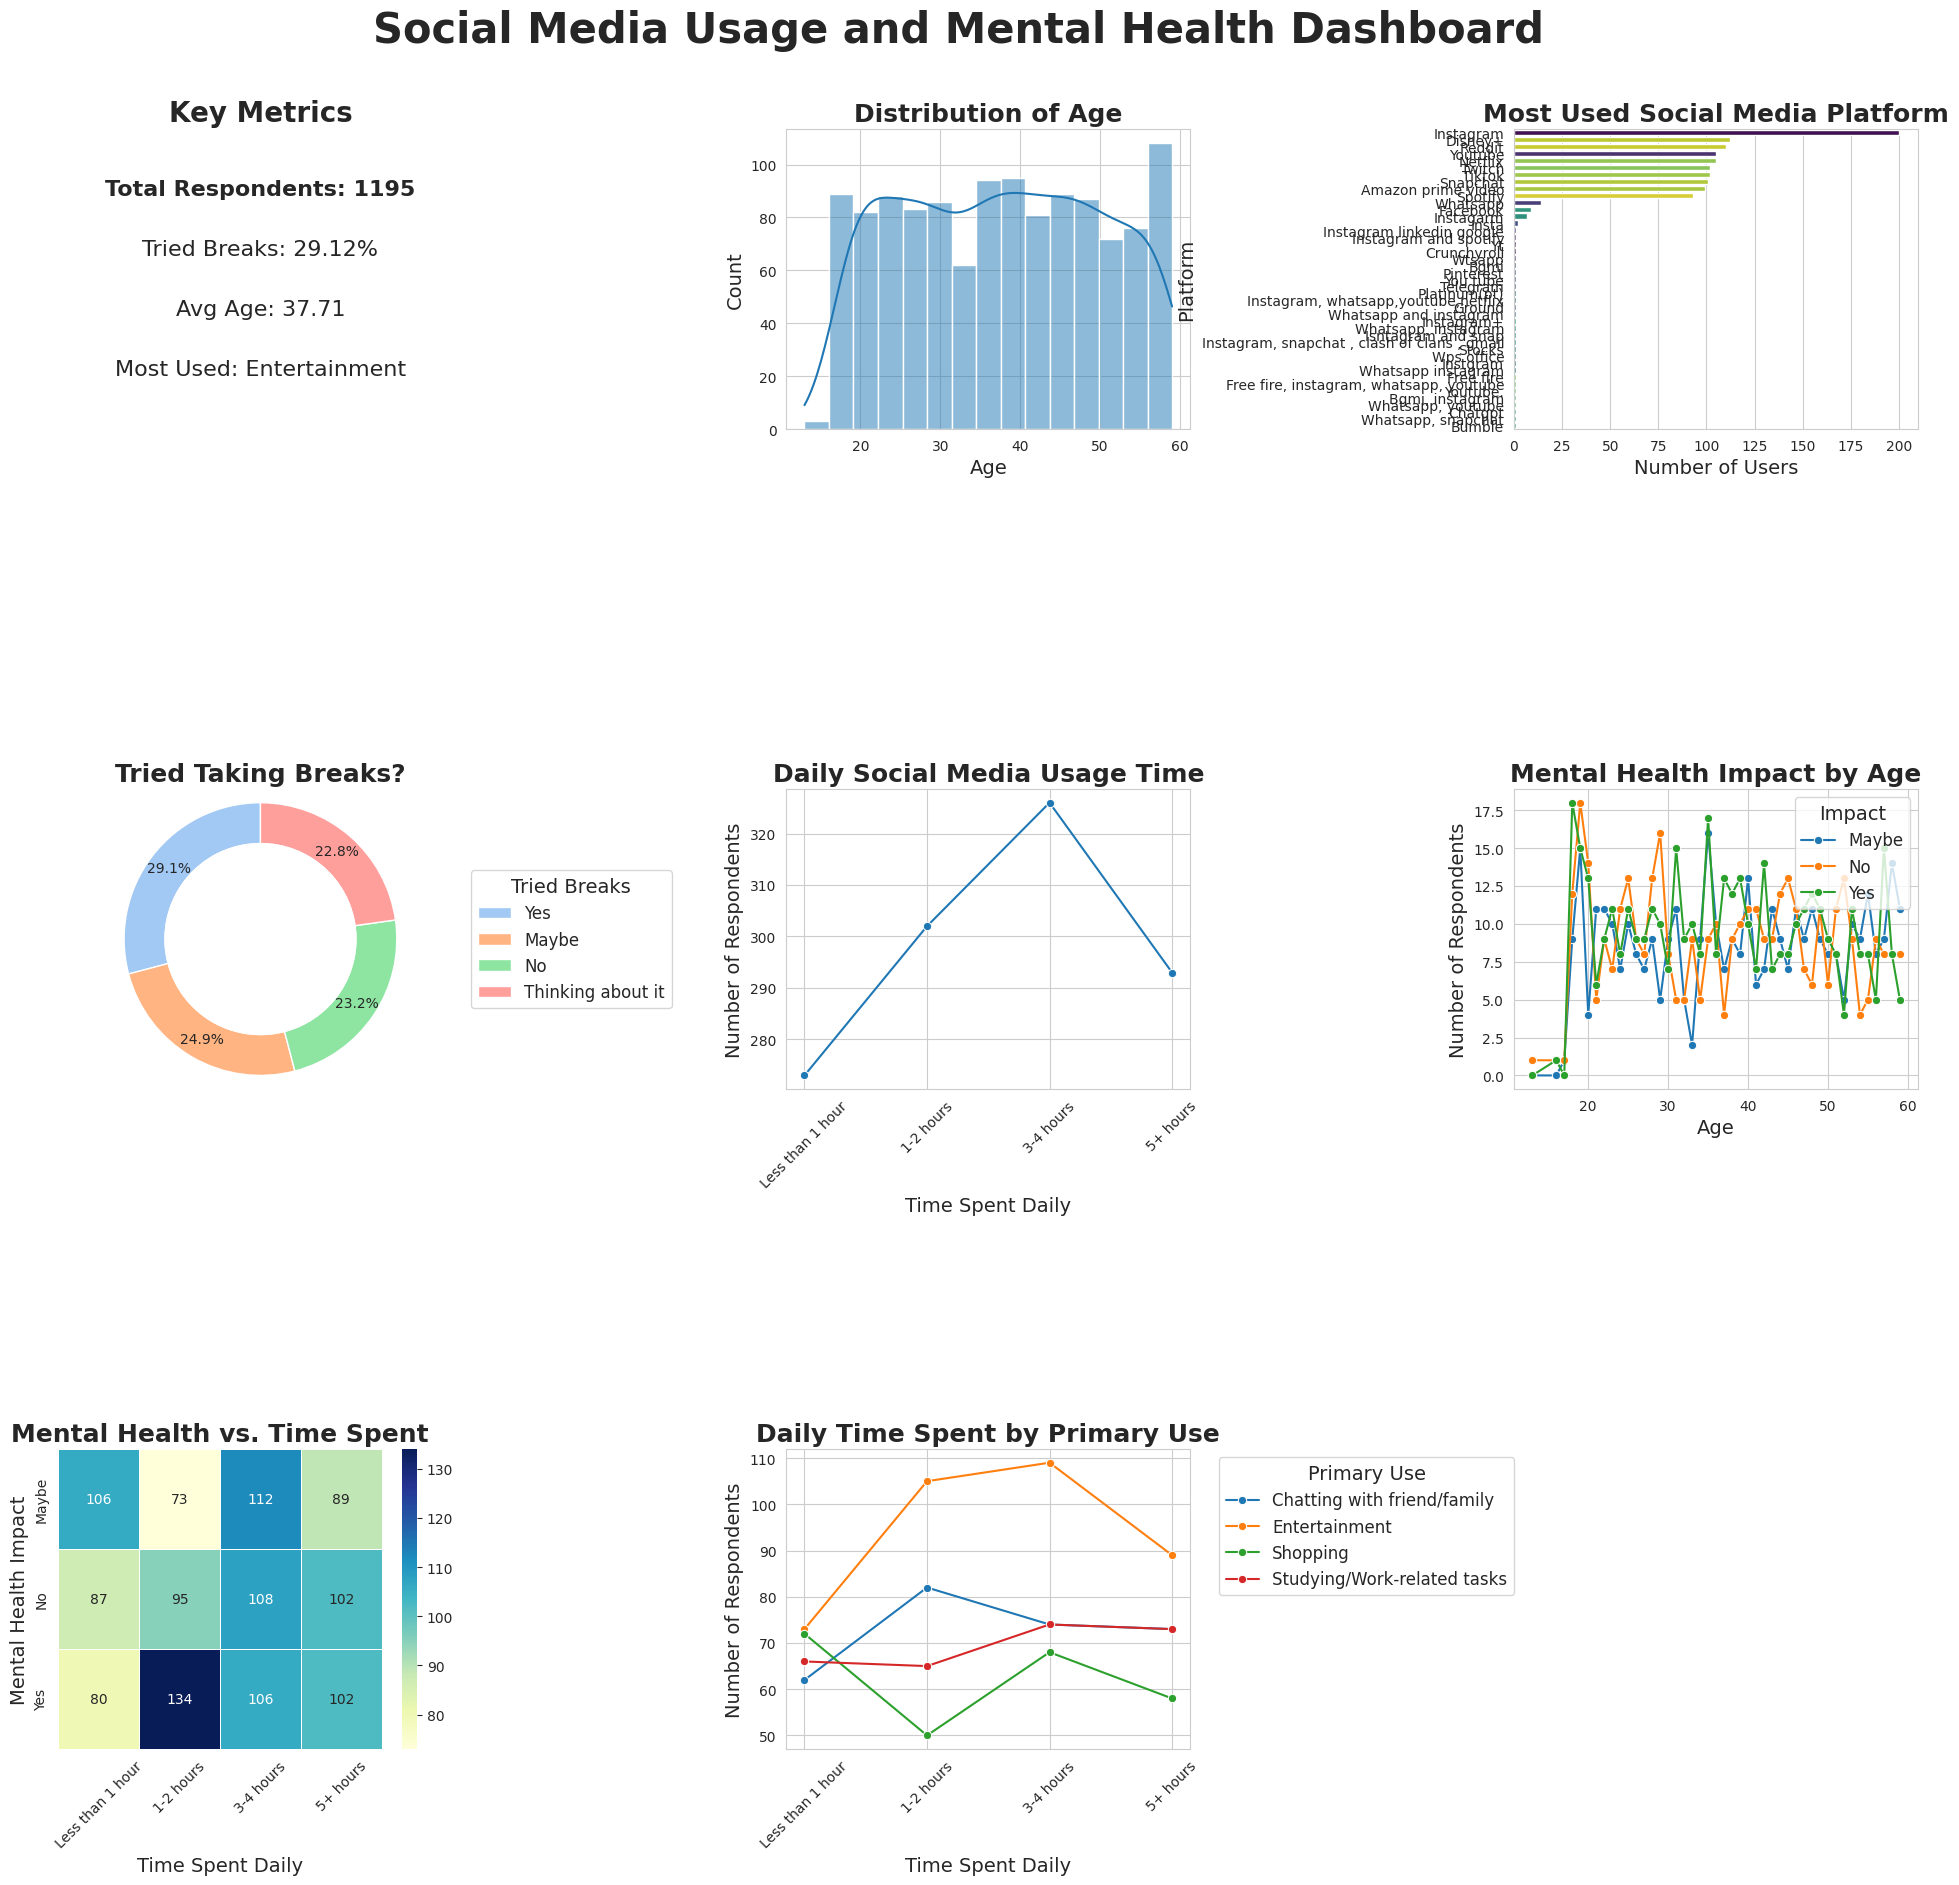

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
import pandas as pd

sns.set_style("whitegrid")

# --- Data Loading and Cleaning (Copied for Dashboard Self-Containment) ---
df = pd.read_csv('/content/Fai Datasets Rishu.csv')

# Clean column names: replace spaces with underscores, convert to lowercase
df.columns = df.columns.str.lower().str.replace(' ', '_').str.replace(':', '').str.replace('?', '')

# Rename some long columns for brevity
df = df.rename(columns={
    'enter_your_age': 'age',
    'which_platform_do_you_use_the_most_daily': 'most_used_platform',
    'on_average,_how_much_time_do_you_spend_on_social_media_per_day': 'time_spent_daily',
    'when_do_you_use_social_media_the_most': 'peak_usage_time',
    'what_do_you_primarily_use_social_media_for': 'primary_use',
    'have_you_ever_tried_to_take_breaks_from_social_media': 'tried_breaks',
    'do_you_feel_social_media_affects_your_mental_health': 'mental_health_impact',
    'what_type_of_content_do_you_engage_with_the_most': 'most_engaged_content',
    'have_you_ever_experienced_online_drama_or_conflict_because_of_social_media': 'experienced_drama',
    'do_you_trust_influencers_product_recommendations': 'trust_influencers_recs',
    'would_you_ever_delete_social_media_permanently': 'delete_permanently'
})

# Drop the 'unnamed: 11' column if it exists and is mostly null
if 'unnamed:_11' in df.columns:
    df = df.drop(columns=['unnamed:_11'])

# Standardize 'most_used_platform' column to consistent casing
df['most_used_platform'] = df['most_used_platform'].str.capitalize()
# --- End of Data Loading and Cleaning ---

# --- Data Aggregation and KPI Calculations (Copied for Dashboard Self-Containment) ---
# Order 'time_spent_daily' for better visualization
time_spent_order = ['Less than 1 hour', '1-2 hours', '3-4 hours', '5+ hours']
df['time_spent_daily'] = pd.Categorical(df['time_spent_daily'], categories=time_spent_order, ordered=True)

# KPI: Total Respondents
num_respondents = len(df)

# KPI Card: Percentage of users who tried taking breaks
tried_breaks_pct = (df['tried_breaks'].value_counts(normalize=True).get('Yes', 0)) * 100

# KPI Card: Most common primary use of social media
most_common_primary_use = df['primary_use'].mode()[0]

# KPI Card: Average Age of Respondents
average_age = df['age'].mean()

# Data for Donut Chart: Tried Taking Breaks from Social Media
break_counts = df['tried_breaks'].value_counts()

# Data for Line Chart: Time Spent Daily Distribution
time_spent_counts = df['time_spent_daily'].value_counts().sort_index()

# Data for Multi-Line Chart: Mental Health Impact by Age Group
mental_health_age = df.groupby(['age', 'mental_health_impact'], observed=False).size().unstack(fill_value=0)

# Data for Heatmap: Mental Health Impact vs. Time Spent Daily
heatmap_data = pd.crosstab(df['mental_health_impact'], df['time_spent_daily'])

# Data for Multi-Line Chart: Daily Time Spent by Primary Use
time_use_data = df.groupby(['time_spent_daily', 'primary_use'], observed=False).size().unstack(fill_value=0)
# --- End of Data Aggregation and KPI Calculations ---


# Create a figure and a GridSpec for more flexible subplot arrangement
fig = plt.figure(figsize=(24, 20))
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=1.2, wspace=0.8) # Increased hspace and wspace for better spacing

# --- KPI Summary (Top-Left, using an ax for text) ---
ax0 = fig.add_subplot(gs[0, 0])
ax0.text(0.5, 0.8, f"Total Respondents: {num_respondents}", ha='center', va='center', fontsize=16, fontweight='bold')
ax0.text(0.5, 0.6, f"Tried Breaks: {tried_breaks_pct:.2f}%", ha='center', va='center', fontsize=16)
ax0.text(0.5, 0.4, f"Avg Age: {average_age:.2f}", ha='center', va='center', fontsize=16)
ax0.text(0.5, 0.2, f"Most Used: {most_common_primary_use}", ha='center', va='center', fontsize=16)
ax0.set_title('Key Metrics', fontsize=20, fontweight='bold')
ax0.axis('off') # Hide axes

# --- Histogram: Age Distribution (Top-Middle) ---
ax1 = fig.add_subplot(gs[0, 1])
sns.histplot(df['age'], bins=15, kde=True, ax=ax1)
ax1.set_title('Distribution of Age', fontsize=18, fontweight='bold')
ax1.set_xlabel('Age', fontsize=14)
ax1.set_ylabel('Count', fontsize=14)

# --- Bar Chart: Most Used Platform (Top-Right) ---
ax2 = fig.add_subplot(gs[0, 2])
sns.countplot(y='most_used_platform', data=df, order=df['most_used_platform'].value_counts().index, palette='viridis', ax=ax2, hue='most_used_platform', legend=False)
ax2.set_title('Most Used Social Media Platform', fontsize=18, fontweight='bold')
ax2.set_xlabel('Number of Users', fontsize=14)
ax2.set_ylabel('Platform', fontsize=14)

# --- Donut Chart: Tried Taking Breaks from Social Media (Middle-Left) ---
ax3 = fig.add_subplot(gs[1, 0])
wedges, texts, autotexts = ax3.pie(break_counts, autopct='%1.1f%%', startangle=90,
                                  colors=sns.color_palette('pastel'),
                                  pctdistance=0.85, wedgeprops=dict(width=0.3))
centre_circle = plt.Circle((0,0),0.70,fc='white')
ax3.add_artist(centre_circle)
ax3.legend(wedges, break_counts.index, title="Tried Breaks", loc="center left", bbox_to_anchor=(1, 0, 0.5, 1), fontsize=12, title_fontsize=14)
ax3.set_title('Tried Taking Breaks?', fontsize=18, fontweight='bold')
ax3.axis('equal')

# --- Line Chart: Time Spent Daily Distribution (Middle-Middle) ---
ax4 = fig.add_subplot(gs[1, 1])
sns.lineplot(x=time_spent_counts.index, y=time_spent_counts.values, marker='o', ax=ax4)
ax4.set_title('Daily Social Media Usage Time', fontsize=18, fontweight='bold')
ax4.set_xlabel('Time Spent Daily', fontsize=14)
ax4.set_ylabel('Number of Respondents', fontsize=14)
ax4.tick_params(axis='x', rotation=45)

# --- Multi-Line Chart: Mental Health Impact by Age Group (Middle-Right) ---
ax5 = fig.add_subplot(gs[1, 2])
for column in mental_health_age.columns:
    sns.lineplot(x=mental_health_age.index, y=mental_health_age[column], label=column, marker='o', ax=ax5)
ax5.set_title('Mental Health Impact by Age', fontsize=18, fontweight='bold')
ax5.set_xlabel('Age', fontsize=14)
ax5.set_ylabel('Number of Respondents', fontsize=14)
ax5.legend(title='Impact', fontsize=12, title_fontsize=14)

# --- Heatmap: Mental Health Impact vs. Time Spent Daily (Bottom-Left) ---
ax6 = fig.add_subplot(gs[2, 0])
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5, ax=ax6)
ax6.set_title('Mental Health vs. Time Spent', fontsize=18, fontweight='bold')
ax6.set_xlabel('Time Spent Daily', fontsize=14)
ax6.set_ylabel('Mental Health Impact', fontsize=14)
ax6.tick_params(axis='x', rotation=45)

# --- Multi-Line Chart: Daily Time Spent by Primary Use (Bottom-Middle) ---
ax7 = fig.add_subplot(gs[2, 1])
for column in time_use_data.columns:
    if column is not None:
        sns.lineplot(x=time_use_data.index, y=time_use_data[column], label=column, marker='o', ax=ax7)
ax7.set_title('Daily Time Spent by Primary Use', fontsize=18, fontweight='bold')
ax7.set_xlabel('Time Spent Daily', fontsize=14)
ax7.set_ylabel('Number of Respondents', fontsize=14)
ax7.legend(title='Primary Use', fontsize=12, title_fontsize=14, bbox_to_anchor=(1.05, 1), loc='upper left')
ax7.tick_params(axis='x', rotation=45)

# --- Placeholder for Treemap (Bottom-Right) ---
ax8 = fig.add_subplot(gs[2, 2]) # Added an empty subplot to maintain grid structure
ax8.axis('off') # Hide axes for this placeholder

# Adjust layout and add a super title for the entire dashboard
plt.suptitle('Social Media Usage and Mental Health Dashboard', fontsize=30, fontweight='bold', y=0.98) # Adjusted y for suptitle
fig.subplots_adjust(top=0.92) # Adjust subplots to make space for suptitle
plt.show()

Interpritation

The dashboard provides a comprehensive overview of social media usage patterns and their perceived impact on mental health. Here's an interpretation:

Key Metrics:

Total Respondents: The analysis is based on data from 1195 individuals.
Tried Breaks: Approximately 29.12% of respondents have tried taking breaks from social media, suggesting a noticeable awareness or concern about their usage.
Average Age: The average age of respondents is about 37.71 years.
Most Used Primary Use: 'Entertainment' is the most common primary use of social media among the respondents.
Visualizations Breakdown:

Distribution of Age: This histogram shows the age distribution of the survey participants, giving an idea of the demographic spread.

Most Used Social Media Platform: This bar chart highlights the most popular social media platforms among the respondents, indicating which platforms dominate their daily usage.

Tried Taking Breaks? (Donut Chart): This chart visually represents the proportion of users who have attempted to take breaks from social media, providing insights into potential addiction or discomfort with their usage habits.

Daily Social Media Usage Time: The line chart illustrates the distribution of how much time respondents spend on social media daily, categorised into different time blocks.

Mental Health Impact by Age: This multi-line chart is crucial for understanding if certain age groups report a higher or lower mental health impact from social media usage.

Mental Health vs. Time Spent (Heatmap): This heatmap displays the correlation between the level of mental health impact and the amount of time spent on social media daily. It can reveal patterns, for example, if increased screen time correlates with a higher reported mental health impact.

Daily Time Spent by Primary Use (Multi-Line Chart): This chart shows how the daily time spent on social media varies depending on the primary reason for using it (e.g., chatting, entertainment, shopping). It helps understand the motivations behind social media engagement.

Overall, the dashboard helps to identify key trends in social media usage, the platforms used, and its potential effects on mental health, broken down by age and primary use. It also indicates a significant number of users consider or act on taking breaks from social media. Remember, the treemap for content engagement is displayed separately and provides a deeper dive into what type of content users interact with on different platforms.